In [1]:
import os
import torch
import pandas as pd
from pathlib import Path

# Path to the split dataset
data_dir = Path("/data/Minerva/20250126_nested_split")

# Get all dataset names
datasets = sorted([d for d in os.listdir(data_dir) if os.path.isdir(data_dir / d)])

In [ ]:
# Dictionary to store counts
counts = {}

# Iterate through each dataset
for dataset in datasets:
    dataset_path = data_dir / dataset
    counts[dataset] = {}
    
    # Count events in each split (train, val, test)
    for split in ['train', 'val', 'test']:
        split_path = dataset_path / split / "0.pb"
        
        if split_path.exists():
            # Load the data
            data = torch.load(split_path, weights_only=False)
            # Count the number of events (first dimension of truth_labels)
            n_events = data['truth_labels'].shape[0]
            counts[dataset][split] = n_events
        else:
            counts[dataset][split] = 0

# Create a DataFrame for nice table display
df = pd.DataFrame(counts).T
df = df[['train', 'val', 'test']]  # Ensure column order

# Add a total column
df['total'] = df.sum(axis=1)

# Add a row for totals
df.loc['Total'] = df.sum()

# Convert to millions
df_millions = df / 1_000_000

print("Number of events per dataset and split (in millions):")
print("=" * 60)
print(df_millions.round(2))
print("=" * 60)

In [11]:

import torch._dynamo
# Iterate through each dataset
dataset_path = data_dir / "1A"

split_path = dataset_path / "train" / "0.pb"

# Load the data
data = torch.load(split_path, weights_only=True, mmap=True)

In [12]:
vals = data["data"].values()
offsets = data["data"].offsets()

In [15]:
vals.shape, offsets.shape, data.keys()

(torch.Size([93186107, 5]),
 torch.Size([6080807]),
 dict_keys(['data', 'truth_labels', 'global_features']))

In [14]:
event_id = 1000003
vals[offsets[event_id]:offsets[event_id+1]]

tensor([[  3.6254,   1.5958,   6.5010,   9.4340,   0.0000],
        [  2.9784,  -0.2567,   2.5593,   4.8471,   2.0000],
        [  2.8913,  -0.0665,   2.1386,   4.3399,   2.0000],
        [  2.4559,   0.1712,   1.8890,   3.6591,   2.0000],
        [  2.7462,  -0.1587,   4.2496,   6.3067,   2.0000],
        [  3.0608,  -0.2078,   2.2186,   4.5885,   2.0000],
        [  2.4861,  -0.6362,   2.8410,   4.6409,   2.0000],
        [  3.1491,  -0.8665,  -0.2604,   2.1973,   2.0000],
        [  2.5946,  -0.6142,   2.2424,   4.1494,   2.0000],
        [  2.5957,  -0.3982,   1.9949,   3.9030,   2.0000],
        [  3.1182,  -0.8834,   1.3768,   3.8038,   2.0000],
        [  2.7952,  -0.8566,   2.4992,   4.6050,   2.0000],
        [  2.7062,  -0.6269,   4.3882,   6.4056,   2.0000],
        [  3.0392,  -1.1521,   0.6339,   2.9822,   2.0000],
        [  2.6218,  -0.5928,  -0.3436,   1.5902,   2.0000],
        [  3.4342,   0.0000,  -1.5308,   1.2113,   2.0000],
        [  3.0129,  -1.0472,  -1.4508,  

In [23]:
import matplotlib.pyplot as plt
def plot_histogram_matrix(title, matrix, feature_names=None):
    # matrix is of dim (N, n_features)
    # for each feature, make a histogram
    fig, axs = plt.subplots(matrix.shape[1], 2, figsize=(12.5, 20))
    for i in range(matrix.shape[1]):
        axs[i, 0].hist(matrix[:, i], bins=100)
        axs[i, 1].hist(matrix[:, i], bins=100)
        axs[i, 1].set_yscale('log')
        if feature_names is None:
            axs[i, 0].set_title(f"Feature {i}")
            axs[i, 0].set_title(f"Feature {i} (log)")
        else:
            axs[i, 0].set_title(feature_names[i])
            axs[i, 1].set_title(feature_names[i])
    fig.suptitle(title)
    return fig



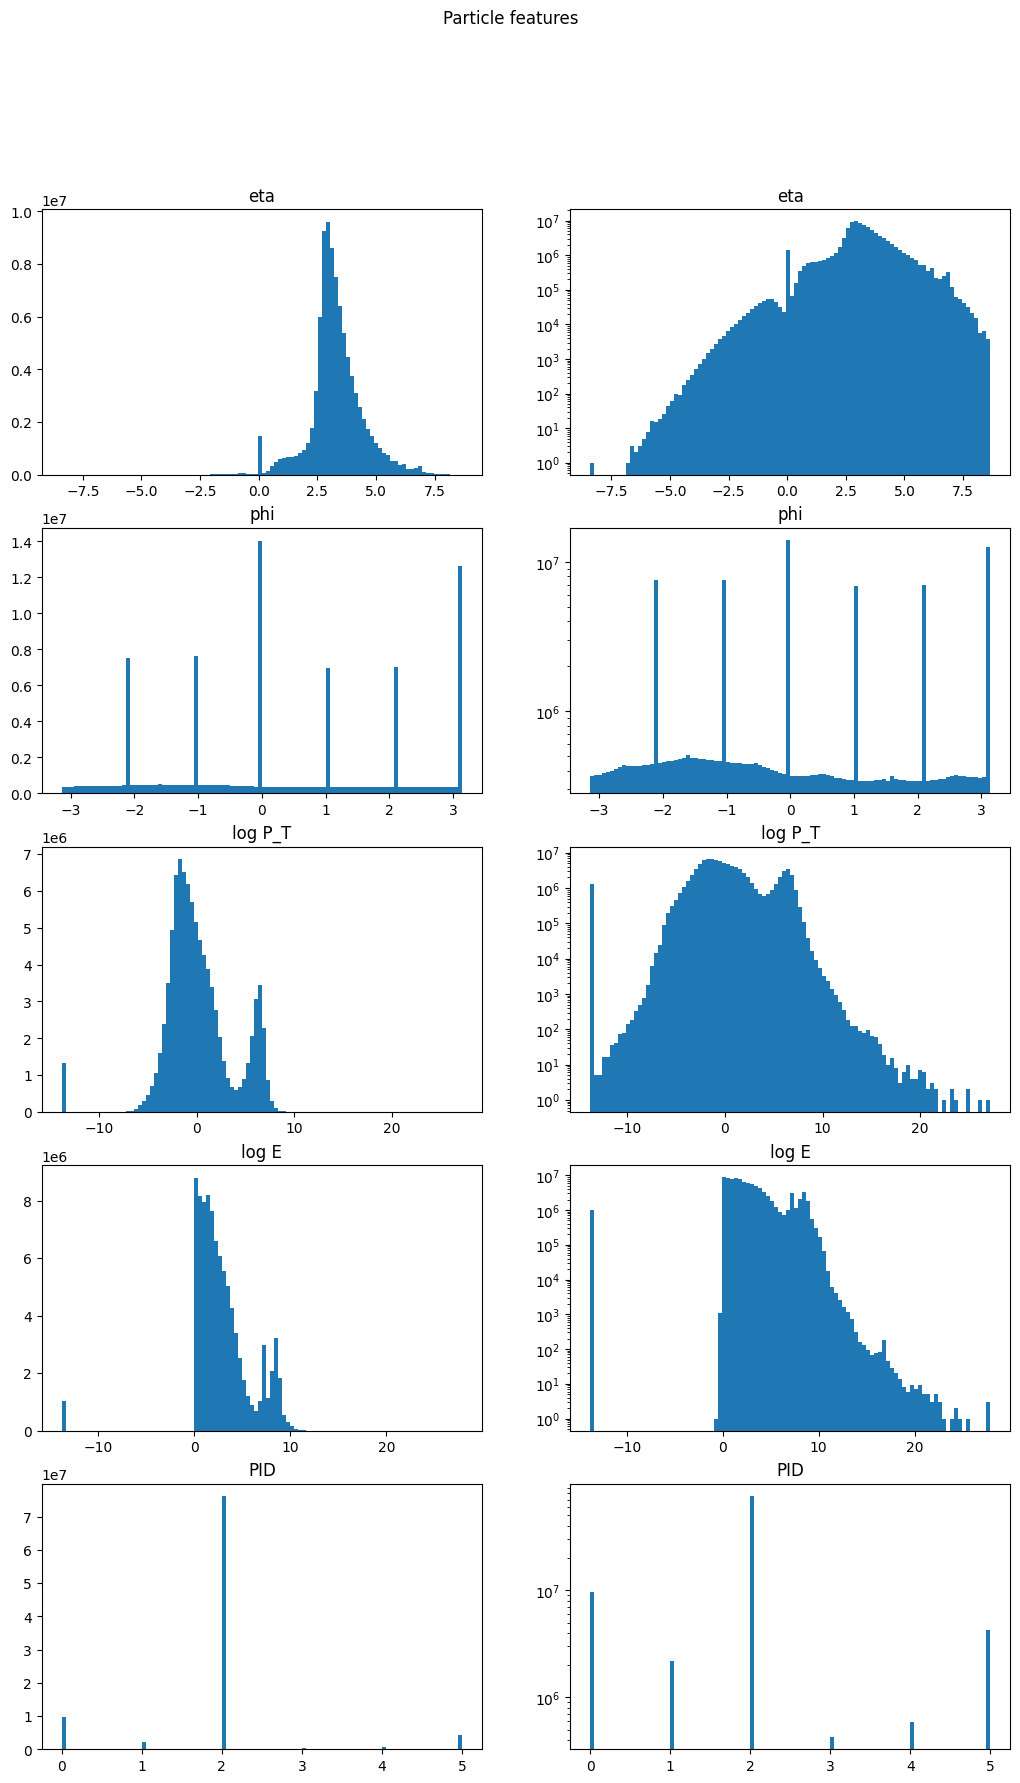

In [24]:
plot_histogram_matrix("Particle features", vals, ["eta", "phi", "log P_T", "log E", "PID"]).show()

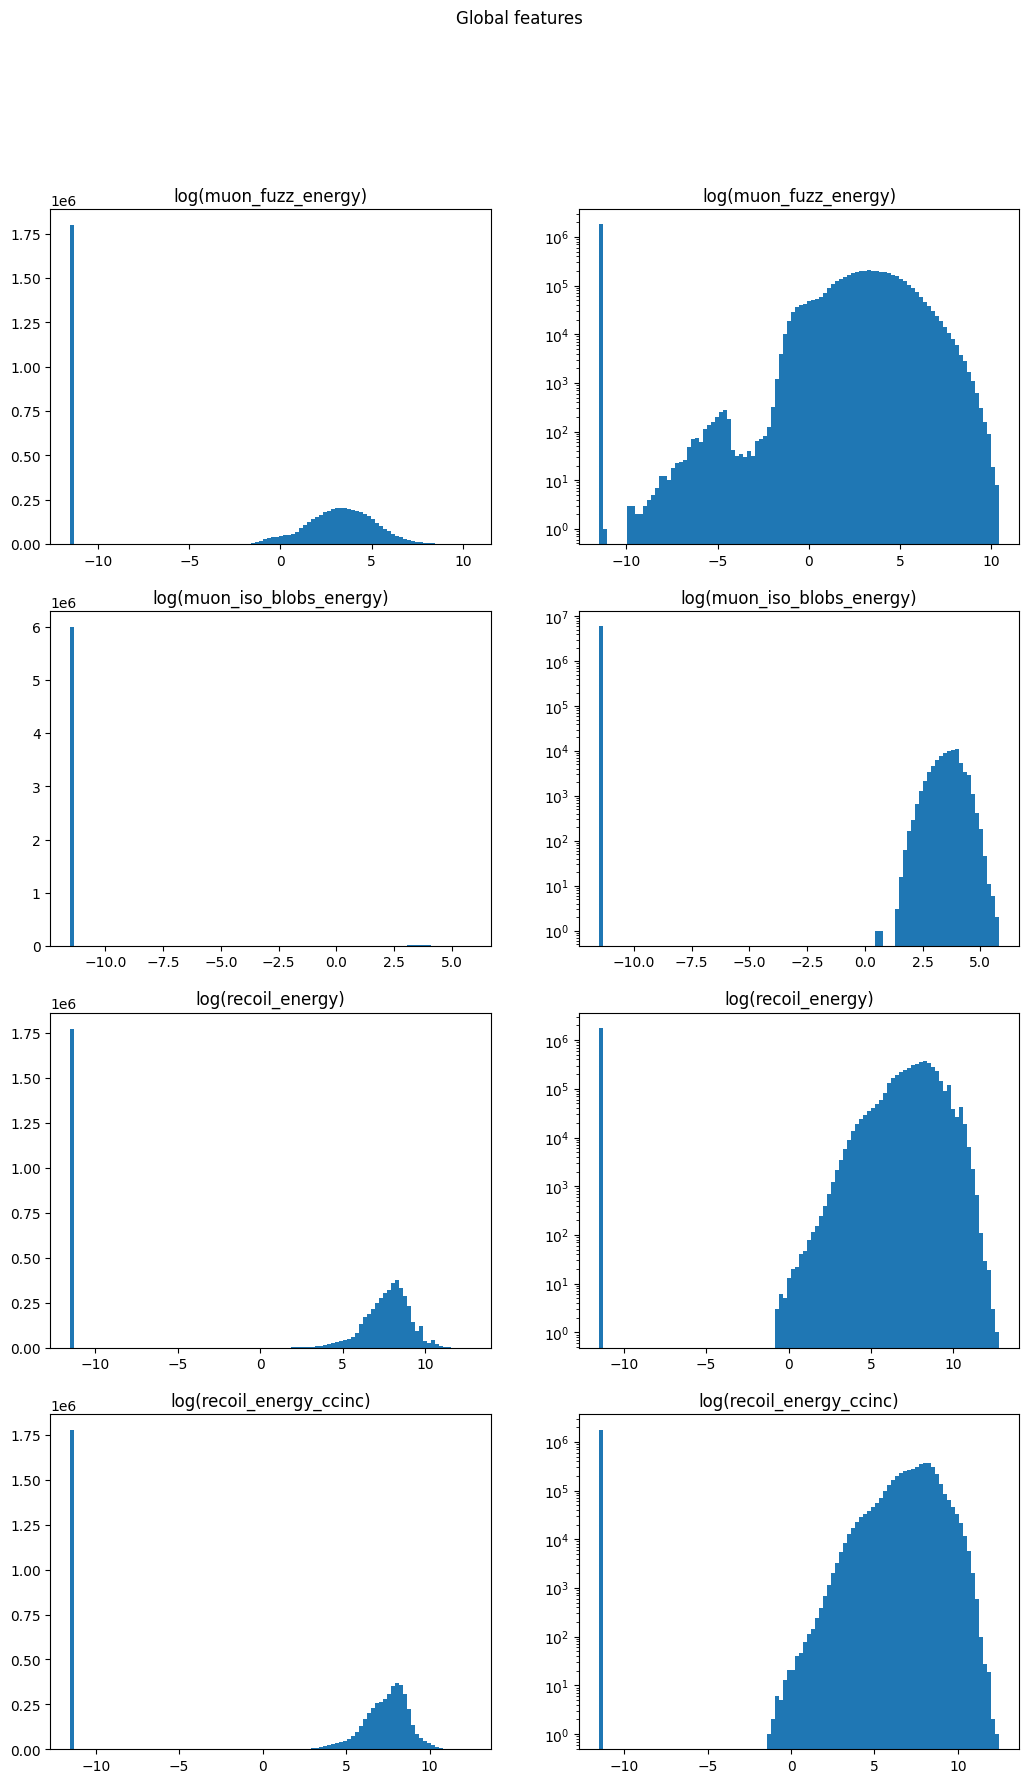

In [25]:
plot_histogram_matrix("Global features", data["global_features"], ["log(muon_fuzz_energy)", "log(muon_iso_blobs_energy)", "log(recoil_energy)", "log(recoil_energy_ccinc)"]).show()

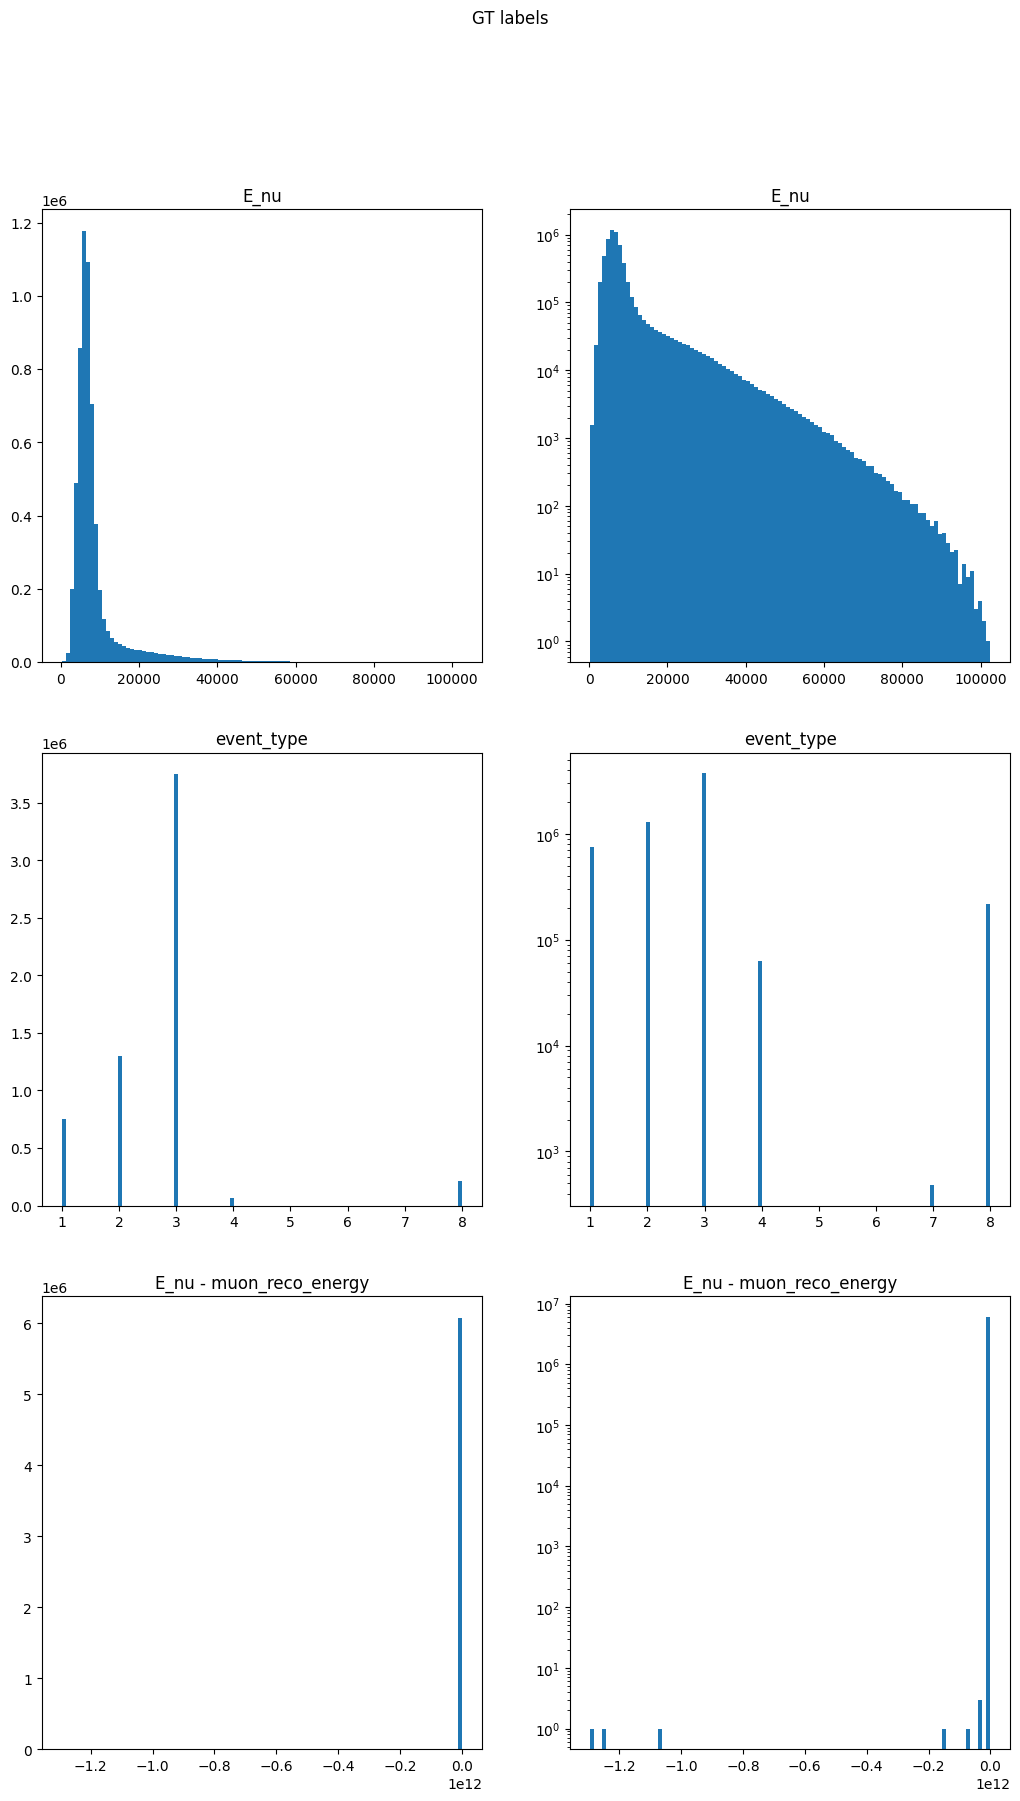

In [26]:
plot_histogram_matrix("GT labels", data["truth_labels"], ["E_nu", "event_type", "E_nu - muon_reco_energy"]).show()

In [31]:
import numpy as np
# check particles with logE <-10 and print their eta, phi, logP_T, logE, PID
particles = vals[np.where(vals[:, 3] < -10)]
print(particles.shape, particles, particles[:, -1])


torch.Size([1027032, 5]) tensor([[  0.0000,   0.0000, -13.8155, -13.8155,   4.0000],
        [  0.0000,   0.0000, -13.8155, -13.8155,   4.0000],
        [  0.0000,   0.0000, -13.8155, -13.8155,   3.0000],
        ...,
        [  0.0000,   0.0000, -13.8155, -13.8155,   3.0000],
        [  0.0000,   0.0000, -13.8155, -13.8155,   4.0000],
        [  0.0000,   0.0000, -13.8155, -13.8155,   3.0000]],
       dtype=torch.float64) tensor([4., 4., 3.,  ..., 3., 4., 3.], dtype=torch.float64)


In [32]:
np.unique(particles[:, -1], return_counts=True)

(array([0., 3., 4., 5.]), array([  4614, 425911, 588506,   8001]))